## Sprint 2. Feature Engineering

This stage builds on the preprocessed and encoded datasets created in **Sprint 1** (`training_encoded.csv`, `test_encoded.csv`).  
The goal is to enrich the feature space with **domain-driven, low-cardinality features** that capture behavioral patterns, vaccine attitudes, and health vulnerability while remaining compatible with the existing encodings.

---

### Load and Inspect the Encoded Data

We begin by loading the baseline encoded datasets from `data/processed/`.  
These contain all categorical encodings (ordinal, one-hot, and target-encoded columns) and numeric features after imputation.

Purpose:
- Provide a clean, fully numeric feature base.
- Avoid handling raw categorical values or missing-value logic again.

---

In [59]:
import pandas as pd
from pathlib import Path

import sys, os
repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.append(repo_root)
    
from src.feature_engineering import engineer_all_features

# --- 1. Load encoded data ---
train_path = Path("../data/processed/training_encoded.csv")
test_path = Path("../data/processed/test_encoded.csv")

train_encoded = pd.read_csv(train_path)
test_encoded = pd.read_csv(test_path)

print(f"Loaded: {train_encoded.shape[0]} train rows, {test_encoded.shape[0]} test rows")

Loaded: 26707 train rows, 26708 test rows



### Apply Feature Engineering Functions

We apply a modular pipeline implemented in `src/feature_engineering.py`, composed of several functions:

##### `add_behavioral_features(df)`

Creates **aggregate indices** from behavioral and opinion-based variables:
- **PBI (Preventive Behavior Index):**  
  Mean of all 7 behavioral indicators → represents how preventive a respondent’s habits are.
- **PVAS_h1n1 / PVAS_seas (Pro-Vaccine Attitude Scores):**  
  Combine vaccine effectiveness, risk, and side-effect opinions into compact attitude metrics.
- **HKI (Health Knowledge Index):**  
  Average of `h1n1_concern` and `h1n1_knowledge`, capturing awareness level.
- **doctor_any:**  
  Binary flags showing whether any doctor recommended vaccination.

These features summarize behavioral tendencies and trust in vaccination.

---

##### `add_socioeconomic_flags(df)`

Generates interpretable **binary indicators** from categorical socioeconomic variables (which include `"Missing"` values):
- `below_poverty` – whether income is coded as “Below Poverty”.
- `low_edu` – lower education (`< 12 Years` or `12 Years`).
- `housing_insecure` – renting or missing housing status.
- `no_job` – unemployed or missing employment status.
- `no_insurance` – missing health insurance.
- `is_married` – marital stability proxy.
- `is_senior` – respondent aged 65+.

These features are robust against “Missing” imputations and help characterize access barriers.

---

##### `add_health_risk_index(df)`

Builds a **Health Risk Index (HRI)** by combining medical and demographic risk factors:

$$
\text{HRI} = \text{chronic\_med\_condition} + \text{child\_under\_6\_months} + \text{health\_worker} + \text{is\_senior} + \text{below\_poverty}
$$

- The result is clipped to 0–4.  
- A higher score implies greater health vulnerability or priority for vaccination.

---

##### `add_interactions(df)`

Adds a small number of **interpretable interaction features** that combine behavior, attitude, and access:
- `PVASxPBI_h1n1` – relationship between attitude and preventive behavior.
- `PVASxDoctor_seas` – influence of doctor recommendation on seasonal vaccine attitude.
- `PBIxNoInsur` – proactive individuals lacking insurance.
- `SeniorxChronic` – elderly people with chronic conditions.
- `PovertyxRent` – compounding economic and housing vulnerability.
- `industry_occ_te_mean` – average of the two target encodings for industry and occupation.

These interactions model joint effects that can be critical for both **vaccine adoption prediction** and **public health targeting**.

---

##### `engineer_all_features(df)`

Combines all previous functions into one clean pipeline:
```python
df.pipe(add_behavioral_features)
  .pipe(add_socioeconomic_flags)
  .pipe(add_health_risk_index)
  .pipe(add_interactions)


In [60]:
# --- 2. Apply feature engineering ---
train_fe = engineer_all_features(train_encoded)
test_fe = engineer_all_features(test_encoded)

print(f"New shapes: {train_fe.shape}, {test_fe.shape}")

New shapes: (26707, 75), (26708, 75)


In [62]:
# --- 3. Inspect new columns ---
new_cols = [c for c in train_fe.columns if c not in train_encoded.columns]
print("Added features:", new_cols)

Added features: ['PBI', 'PVAS_h1n1', 'PVAS_seas', 'HKI', 'doctor_any', 'doctor_gap', 'below_poverty', 'low_edu', 'housing_insecure', 'no_job', 'no_insurance', 'is_married', 'is_senior', 'HRI', 'PVASxPBI_h1n1', 'PVASxDoctor_seas', 'PBIxNoInsur', 'SeniorxChronic', 'PovertyxRent', 'industry_occ_te_mean']


In [54]:
# Load targets
labels = pd.read_csv("../data/raw/training_set_labels.csv")

# Merge into the engineered training data
train_fe = train_fe.copy()
train_fe["h1n1_vaccine"] = labels["h1n1_vaccine"]
train_fe["seasonal_vaccine"] = labels["seasonal_vaccine"]

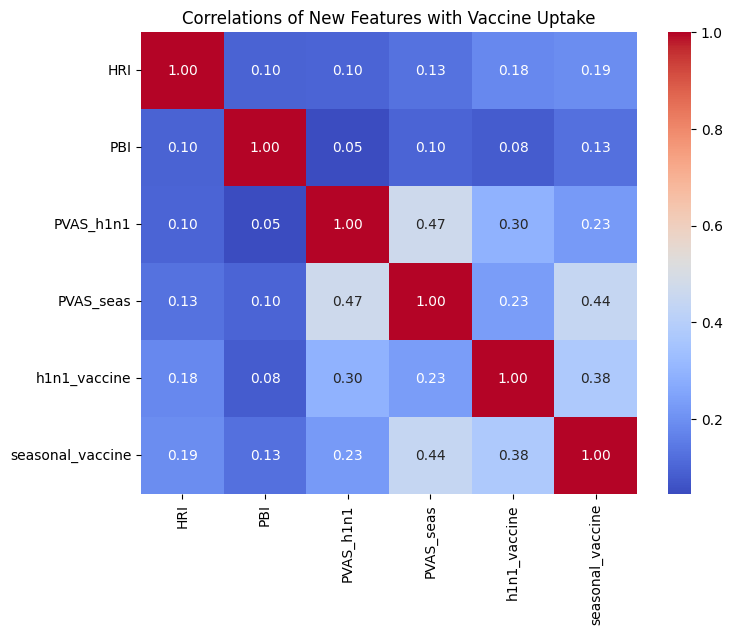

In [55]:
# Check correlation between new indices and vaccine uptake
import seaborn as sns
import matplotlib.pyplot as plt

corr_targets = train_fe[["HRI", "PBI", "PVAS_h1n1", "PVAS_seas"] + ["h1n1_vaccine", "seasonal_vaccine"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_targets, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlations of New Features with Vaccine Uptake")
plt.show()

### Validate Engineered Features

After generating all new features, we perform a **validation check** to ensure data quality and consistency before saving the enhanced datasets.

The validation function `validate_engineered_features(df)` performs several automatic tests:

| Validation | Description |
|:--|:--|
| **Feature presence check** | Confirms that all expected engineered columns (e.g., `PBI`, `PVAS_h1n1`, `HRI`, etc.) exist in the dataset. |
| **Numeric type enforcement** | Ensures every engineered feature is numeric: no string or categorical values remain. |
| **Missing value check** | Verifies that none of the engineered features contain `NaN` values after processing. |
| **Range checks** | Confirms logical bounds for key indices:<br>– `PBI` ∈ [0, 1]<br>– `HRI` ∈ [0, 4] |
| **Console confirmation** | Prints `Feature validation passed: all checks OK.` if everything is valid. |

This step guarantees that the engineered dataset is safe for downstream modeling and that no invalid values were introduced during feature creation.

In [56]:
from src.feature_engineering import validate_engineered_features

# Validate engineered training dataset
validate_engineered_features(train_fe)

# Optional: test dataset validation
validate_engineered_features(test_fe)


✅ Feature validation passed: all checks OK.
✅ Feature validation passed: all checks OK.


In [57]:
# Create a reduced dataset
drop_cols = [
    # redundant behavioral/opinion components
    *[c for c in train_fe.columns if c.startswith("behavioral_")],
    *[c for c in train_fe.columns if c.startswith("opinion_")],
    "h1n1_concern", "h1n1_knowledge",
    "doctor_recc_h1n1", "doctor_recc_seasonal"
]

train_reduced = train_fe.drop(columns=drop_cols, errors="ignore")
test_reduced = test_fe.drop(columns=drop_cols, errors="ignore")

print(f"Reduced train shape: {train_reduced.shape}")


Reduced train shape: (26707, 60)


#### Save Full and Reduced Feature Sets

After validating the engineered data, we export two versions of the final datasets:

- **`training_fe_full.csv` / `test_fe_full.csv`**  
  Contain **all original encoded features** plus the **new engineered features** (indices, flags, and interactions).  
  These versions are ready for comprehensive model experimentation and feature importance analysis.

- **`training_fe_reduced.csv` / `test_fe_reduced.csv`**  
  Contain a **trimmed feature set** where redundant raw columns (e.g., individual behavioral and opinion features already summarized in composite indices) are removed.  
  These lighter versions are optimized for faster training and reduced multicollinearity in production models.

In [58]:
train_fe.to_csv("../data/processed/training_fe_full.csv", index=False)
test_fe.to_csv("../data/processed/test_fe_full.csv", index=False)
train_reduced.to_csv("../data/processed/training_fe_reduced.csv", index=False)
test_reduced.to_csv("../data/processed/test_fe_reduced.csv", index=False)

#### Feature Engineering Outcomes

| Category             | New Features                                   | Purpose                        |
| :------------------- | :--------------------------------------------- | :----------------------------- |
| Behavioral / Opinion | PBI, PVAS_h1n1, PVAS_seas, HKI                 | Capture habits and attitudes   |
| Socioeconomic Flags  | below_poverty, low_edu, housing_insecure, etc. | Describe access barriers       |
| Health Risk          | HRI                                            | Identify high-risk individuals |
| Interactions         | PVASxPBI_h1n1, SeniorxChronic, etc.            | Model combined effects         |
| Encoded Mean         | industry_occ_te_mean                           | Aggregate occupational signal  |

These engineered features bridge the gap between predictive modeling and actionable insights, enabling:

- Identification of vulnerable groups for targeted health interventions.
- Discovery of high-conversion segments for commercial vaccination campaigns.